# MS-mPPCA vs. Vanilla mPPCA: сравнительный анализ

Прямое сопоставление двух моделей на S&P 500 (2005–2024):

| Модель | Структура |
|---|---|
| **Vanilla mPPCA** | i.i.d. смесь: $p(x_t) = \sum_k \pi_k \mathcal{N}(x_t \mid \mu_k, C_k)$ |
| **MS-mPPCA** | HMM с mPPCA-эмиссиями: $z_t \mid z_{t-1} \sim \text{Cat}(A_{z_{t-1},\cdot})$, $x_t \mid z_t \sim \mathcal{N}(\mu_{z_t}, C_{z_t})$ |

**Ключевой вопрос**: устраняет ли марковская структура кластеризацию нарушений VaR?

In [36]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import download
from src.data.preprocessing import get_returns_array
from src.models.rolling import load as load_vanilla, load_ms, fit_rolling_ms, save_ms
from src.models.var import compute_var_multi_level
from src.backtesting.portfolios import generate_diversified, generate_non_diversified
from src.backtesting.backtest import aggregate_results, breach_series

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})
sns.set_palette('tab10')

VANILLA_ARTIFACT = '../data/basic-pipeline/rolling_fit.npz'
MS_RUN_DIR       = '../data/ms-mppca'
MS_ARTIFACT      = f'{MS_RUN_DIR}/rolling_fit_ms.npz'
WINDOW      = 350
ALPHAS      = [0.05, 0.01]
N_PORT      = 200

import os
os.makedirs(MS_RUN_DIR, exist_ok=True)

## 1. Загрузка данных и vanilla mPPCA

In [37]:
prices = download(cache=True)
returns, dates, tickers = get_returns_array(prices)
T, D = returns.shape

vanilla = load_vanilla(VANILLA_ARTIFACT)
T_out   = vanilla.means_hist.shape[0]
K       = vanilla.means_hist.shape[1]
q       = vanilla.W_hist.shape[3]
D_art   = vanilla.means_hist.shape[2]   # D stored in artifact

# Guard: artifact and returns must have the same number of assets.
# Mismatch means the artifact was fit on a different download than the current cache.
# Fix: delete the artifact and re-run `python main.py --force-refit`, OR
#      delete data/sp500_adj_close.csv to force a fresh download matching the artifact.
assert D == D_art, (
    f"D mismatch: returns have {D} assets but artifact was fit on {D_art}. "
    f"Delete {'the artifact' if D > D_art else 'data/sp500_adj_close.csv'} and re-run main.py."
)

oos_dates = dates[WINDOW : WINDOW + T_out]
oos_ret   = returns[WINDOW : WINDOW + T_out]
eq_w      = np.ones(D) / D

print(f'Assets D={D}, latent q={q}, regimes K={K}')
print(f'OOS windows: {T_out}  ({oos_dates[0].date()} -> {oos_dates[-1].date()})')

Loading cached data from /Users/ivan/Projects/mipt/ms-mppca-coupling-diploma/notebooks/../data/sp500_adj_close.csv
Assets D=79, latent q=3, regimes K=2
OOS windows: 4681  (2006-05-25 -> 2024-12-30)


## 2. Обучение MS-mPPCA

Если артефакт уже существует — загружается, переобучение не запускается.

In [38]:
import os

if os.path.exists(MS_ARTIFACT):
    print(f'Loading MS artifact from {MS_ARTIFACT}')
    ms = load_ms(MS_ARTIFACT)
else:
    print('Fitting MS-mPPCA rolling (this takes ~5-7 min)...')
    ms = fit_rolling_ms(
        returns,
        window=WINDOW,
        step=1,
        n_components=q,
        n_clusters=K,
        n_iter_init=2000,
        n_iter_ms_init=200,
        n_iter_ms=100,
        tol_ms=1e-3,
        sticky_diag=2.0,
        hmm_eps=0.05,
        random_state=42,
    )
    save_ms(ms, MS_ARTIFACT)
    print(f'Saved to {MS_ARTIFACT}')

print(f'MS-mPPCA windows: {ms.means_hist.shape[0]}')
print(f'A diagonal (mean over time): {ms.A_hist[:, range(K), range(K)].mean(axis=0).round(4)}')

Loading MS artifact from ../data/ms-mppca/rolling_fit_ms.npz
MS-mPPCA windows: 4681
A diagonal (mean over time): [0.7987 0.6186]


## 3. Сравнение log-likelihood

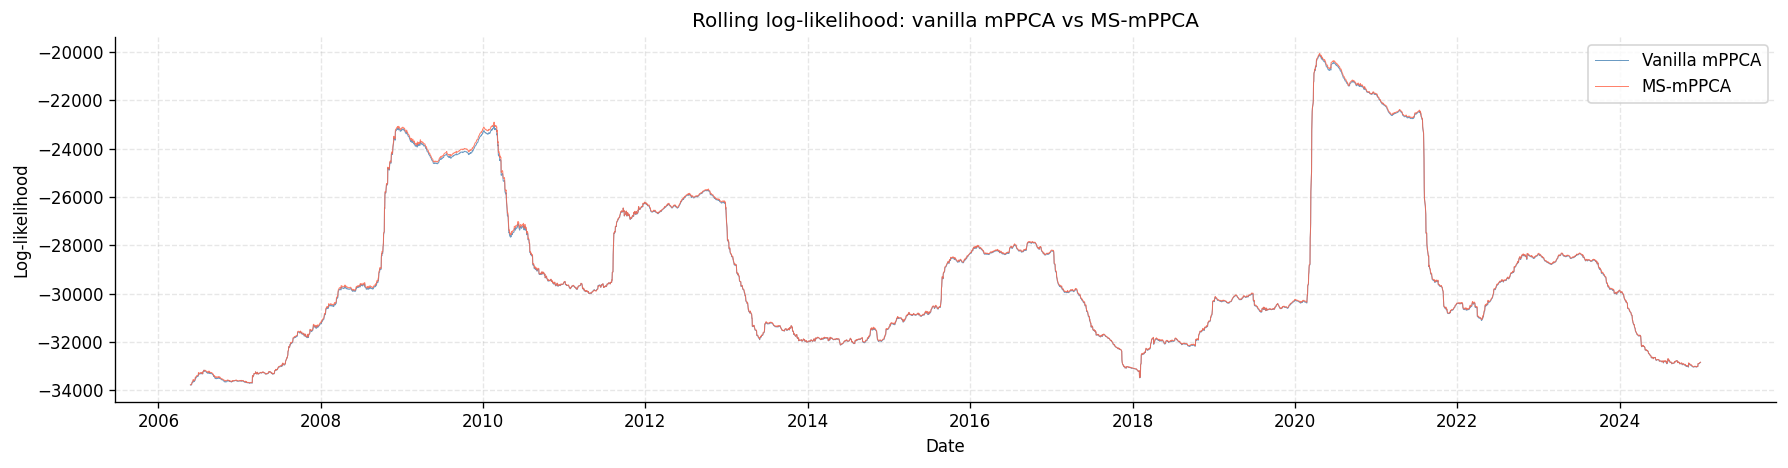

Mean LLH gain (MS - vanilla): 30.91
MS-mPPCA improves LLH in 99.1% of windows


In [39]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(oos_dates, vanilla.llh_hist, lw=0.6, color='steelblue', alpha=0.8, label='Vanilla mPPCA')
ax.plot(oos_dates, ms.llh_hist,      lw=0.6, color='tomato',    alpha=0.8, label='MS-mPPCA')
ax.set_title('Rolling log-likelihood: vanilla mPPCA vs MS-mPPCA')
ax.set_xlabel('Date')
ax.set_ylabel('Log-likelihood')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig(f'{MS_RUN_DIR}/fig_llh_compare.png', bbox_inches='tight')
plt.show()

diff = ms.llh_hist - vanilla.llh_hist
print(f'Mean LLH gain (MS - vanilla): {diff.mean():.2f}')
print(f'MS-mPPCA improves LLH in {(diff > 0).mean()*100:.1f}% of windows')

## 4. Анализ режимов MS-mPPCA

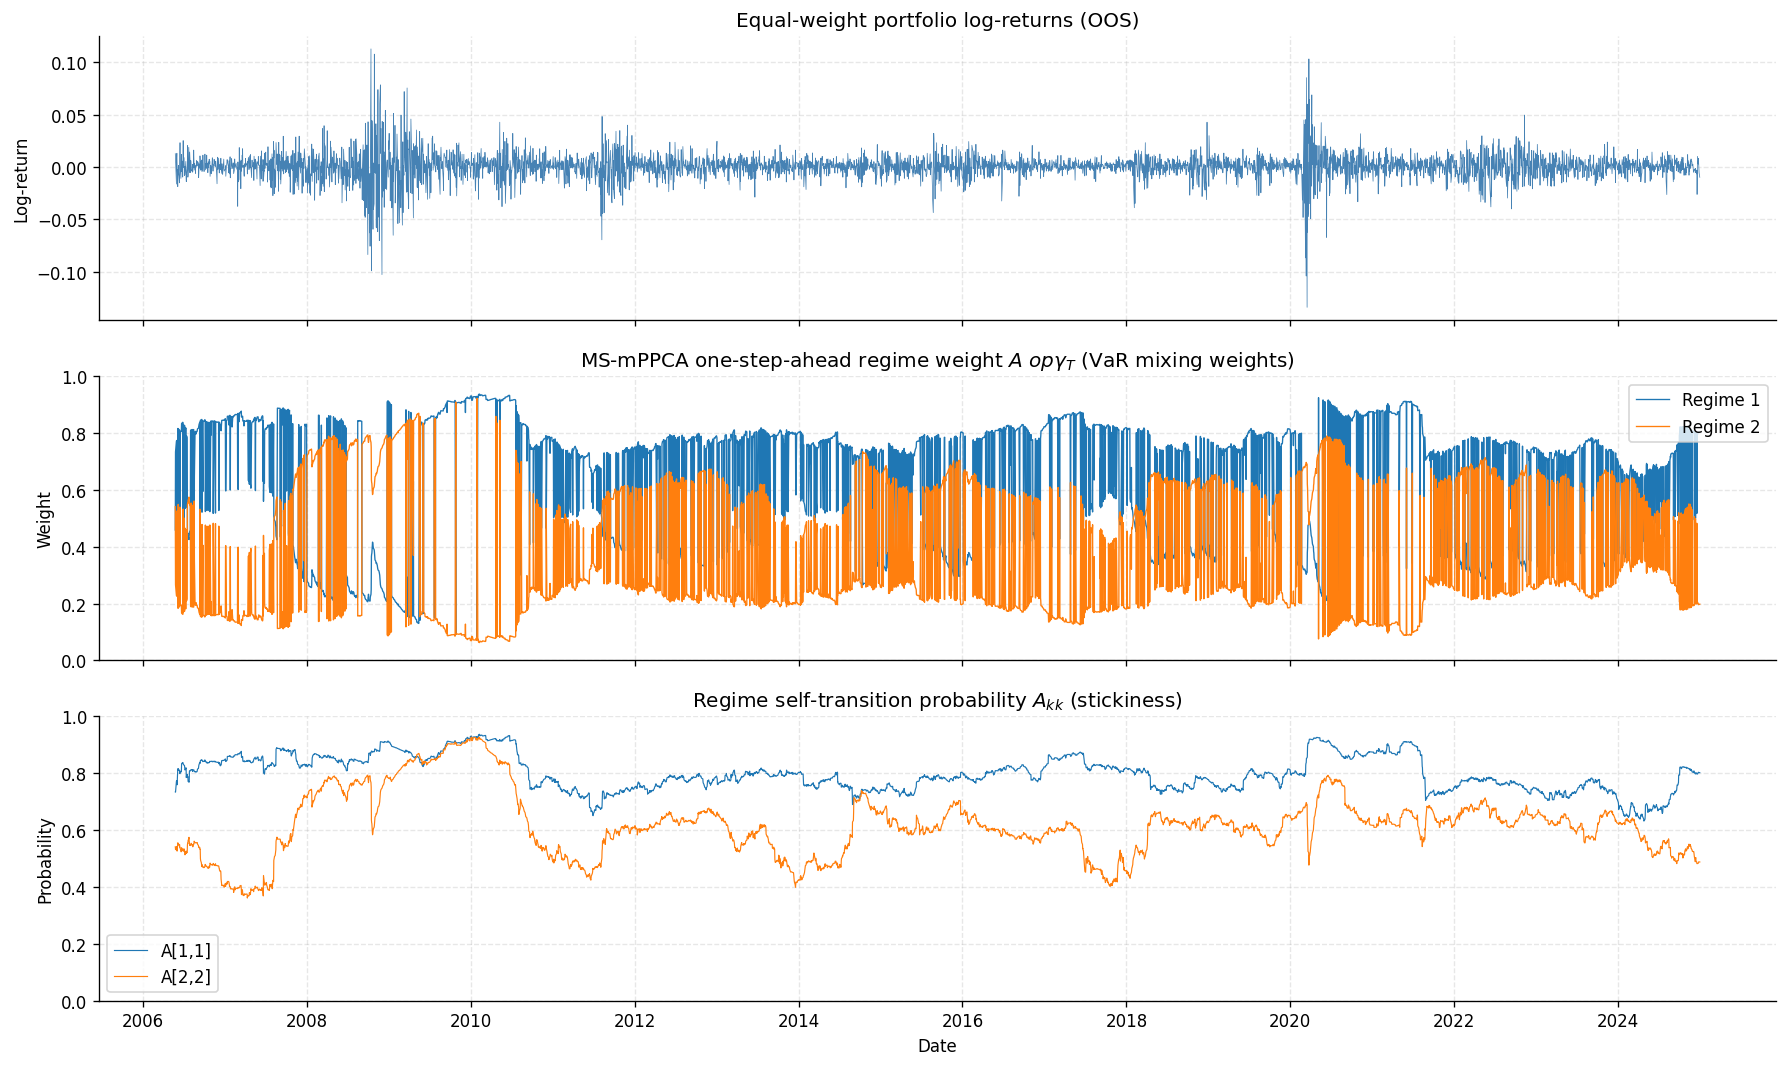

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

# Return series
port_oos = oos_ret @ eq_w
axes[0].plot(oos_dates, port_oos, lw=0.45, color='steelblue')
axes[0].set_title('Equal-weight portfolio log-returns (OOS)')
axes[0].set_ylabel('Log-return')

# Predicted one-step-ahead regime weights (used for VaR)
for k in range(K):
    axes[1].plot(oos_dates, ms.predicted_pi_next_hist[:, k], lw=0.8, label=f'Regime {k+1}')
axes[1].set_title('MS-mPPCA one-step-ahead regime weight $A^\top \gamma_T$ (VaR mixing weights)')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, 1)
axes[1].legend()

# Self-transition probability A_kk (regime stickiness)
for k in range(K):
    axes[2].plot(oos_dates, ms.A_hist[:, k, k], lw=0.7, label=f'A[{k+1},{k+1}]')
axes[2].set_title('Regime self-transition probability $A_{kk}$ (stickiness)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Probability')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(f'{MS_RUN_DIR}/fig_regimes.png', bbox_inches='tight')
plt.show()

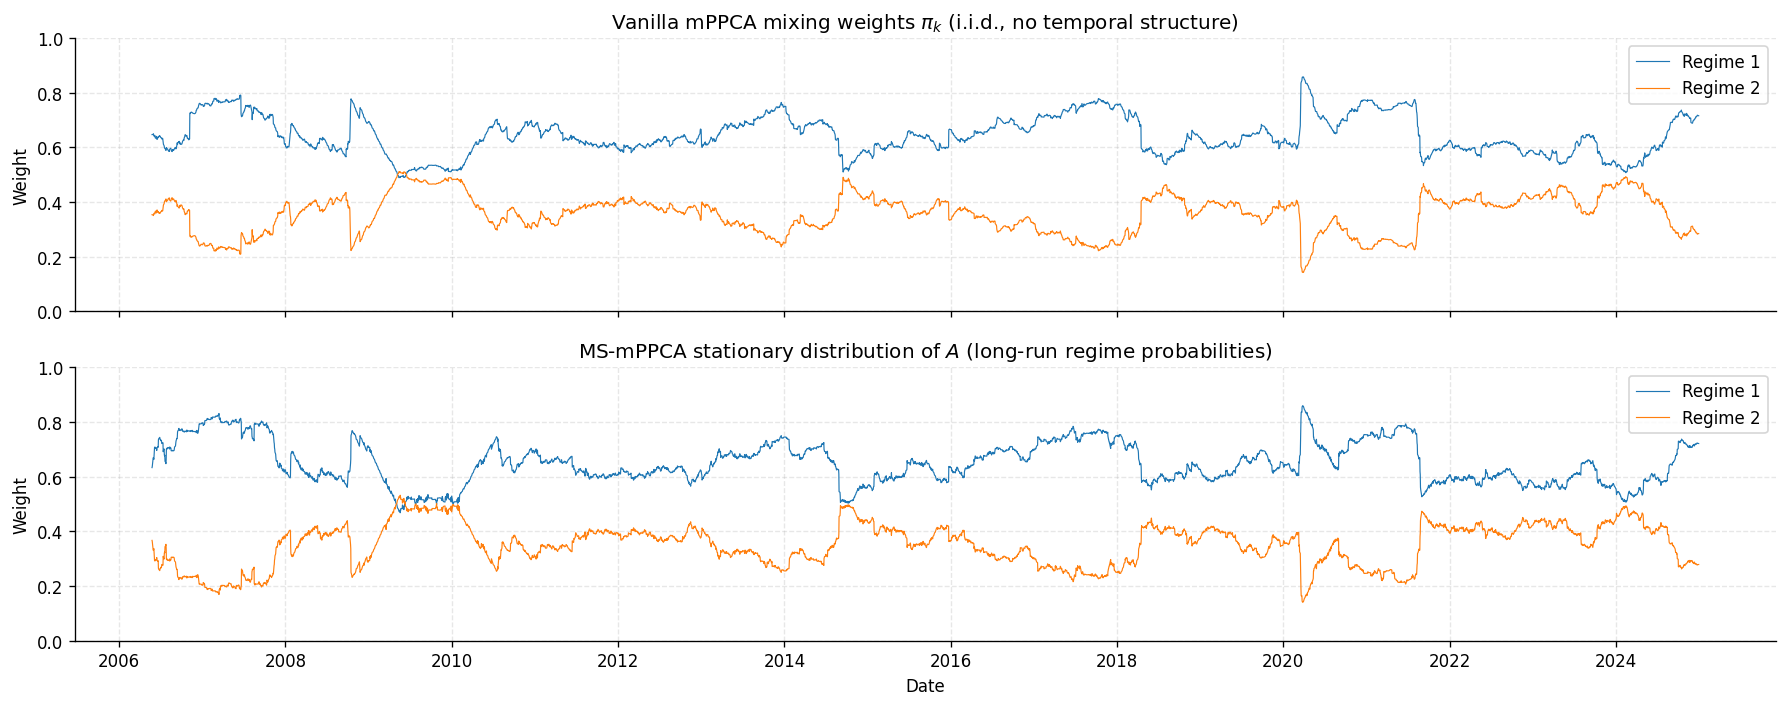

In [41]:
# Vanilla mixing weights vs MS one-step-ahead weights
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
for k in range(K):
    axes[0].plot(oos_dates, vanilla.weights_hist[:, k], lw=0.7, label=f'Regime {k+1}')
axes[0].set_title('Vanilla mPPCA mixing weights $\pi_k$ (i.i.d., no temporal structure)')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, 1)
axes[0].legend()

for k in range(K):
    axes[1].plot(oos_dates, ms.stationary_hist[:, k], lw=0.7, label=f'Regime {k+1}')
axes[1].set_title('MS-mPPCA stationary distribution of $A$ (long-run regime probabilities)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(f'{MS_RUN_DIR}/fig_weights_compare.png', bbox_inches='tight')
plt.show()

## 5. VaR: временные ряды и нарушения

In [42]:
portfolios_div    = generate_diversified(N_PORT, D)
portfolios_nondiv = generate_non_diversified(N_PORT, D)

# Compute VaR for both models
vars_vanilla_div  = compute_var_multi_level(vanilla, portfolios_div,    ALPHAS)
vars_vanilla_nd   = compute_var_multi_level(vanilla, portfolios_nondiv, ALPHAS)
vars_ms_div       = compute_var_multi_level(ms,      portfolios_div,    ALPHAS)
vars_ms_nd        = compute_var_multi_level(ms,      portfolios_nondiv, ALPHAS)

# Equal-weight portfolio VaR for visual comparison
eq_w_2d = eq_w.reshape(1, -1)
vars_v_eq = compute_var_multi_level(vanilla, eq_w_2d, ALPHAS)
vars_ms_eq = compute_var_multi_level(ms,     eq_w_2d, ALPHAS)

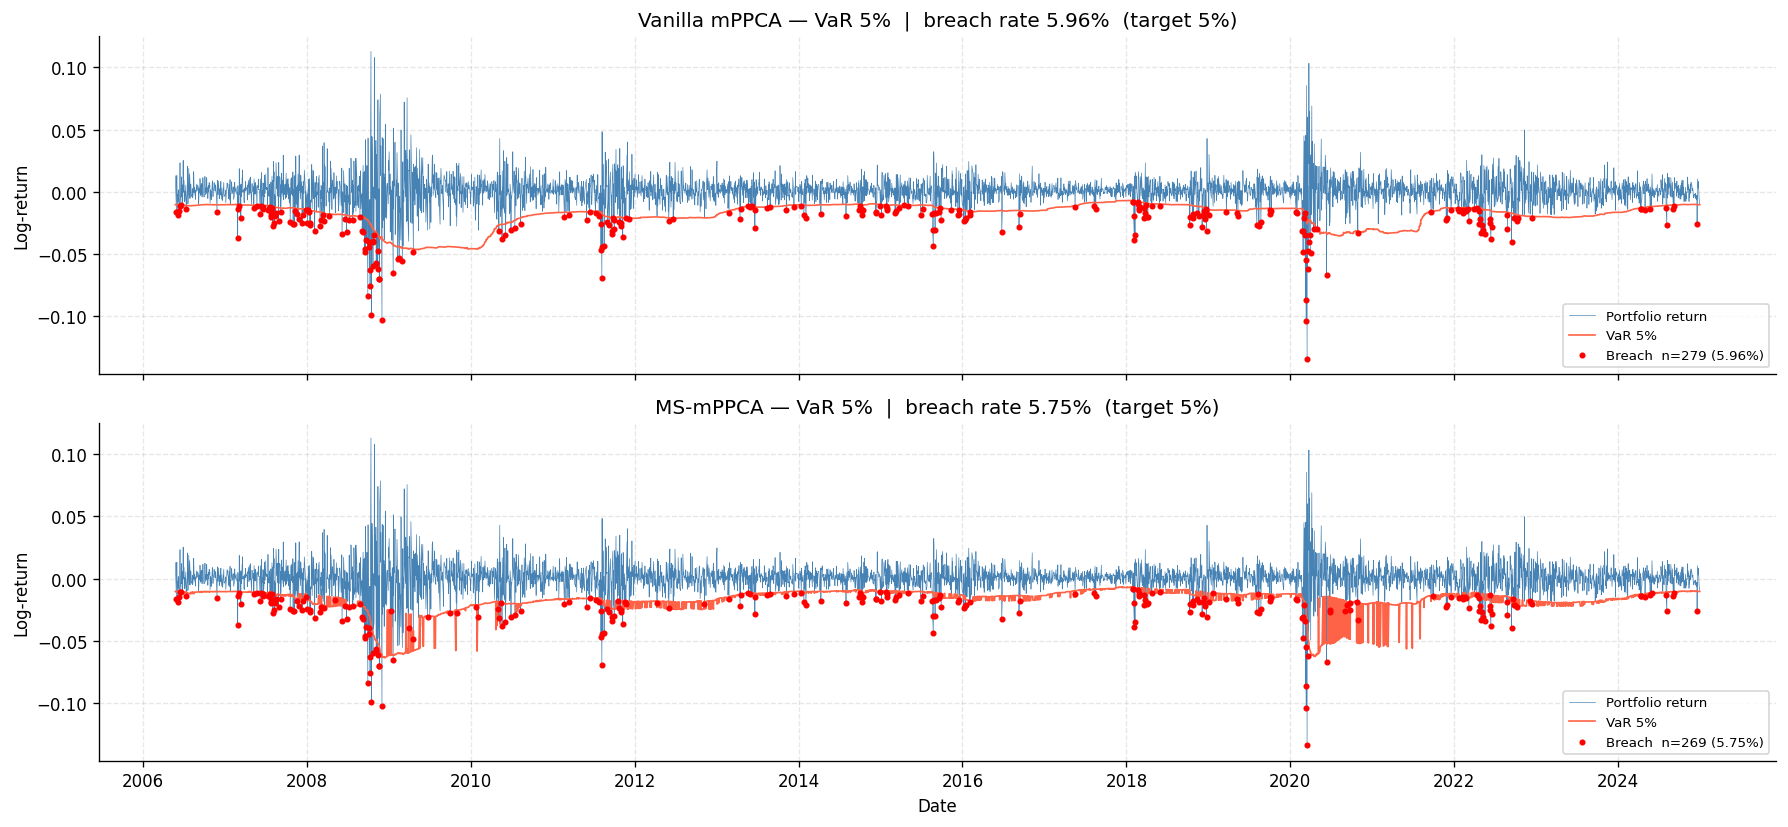

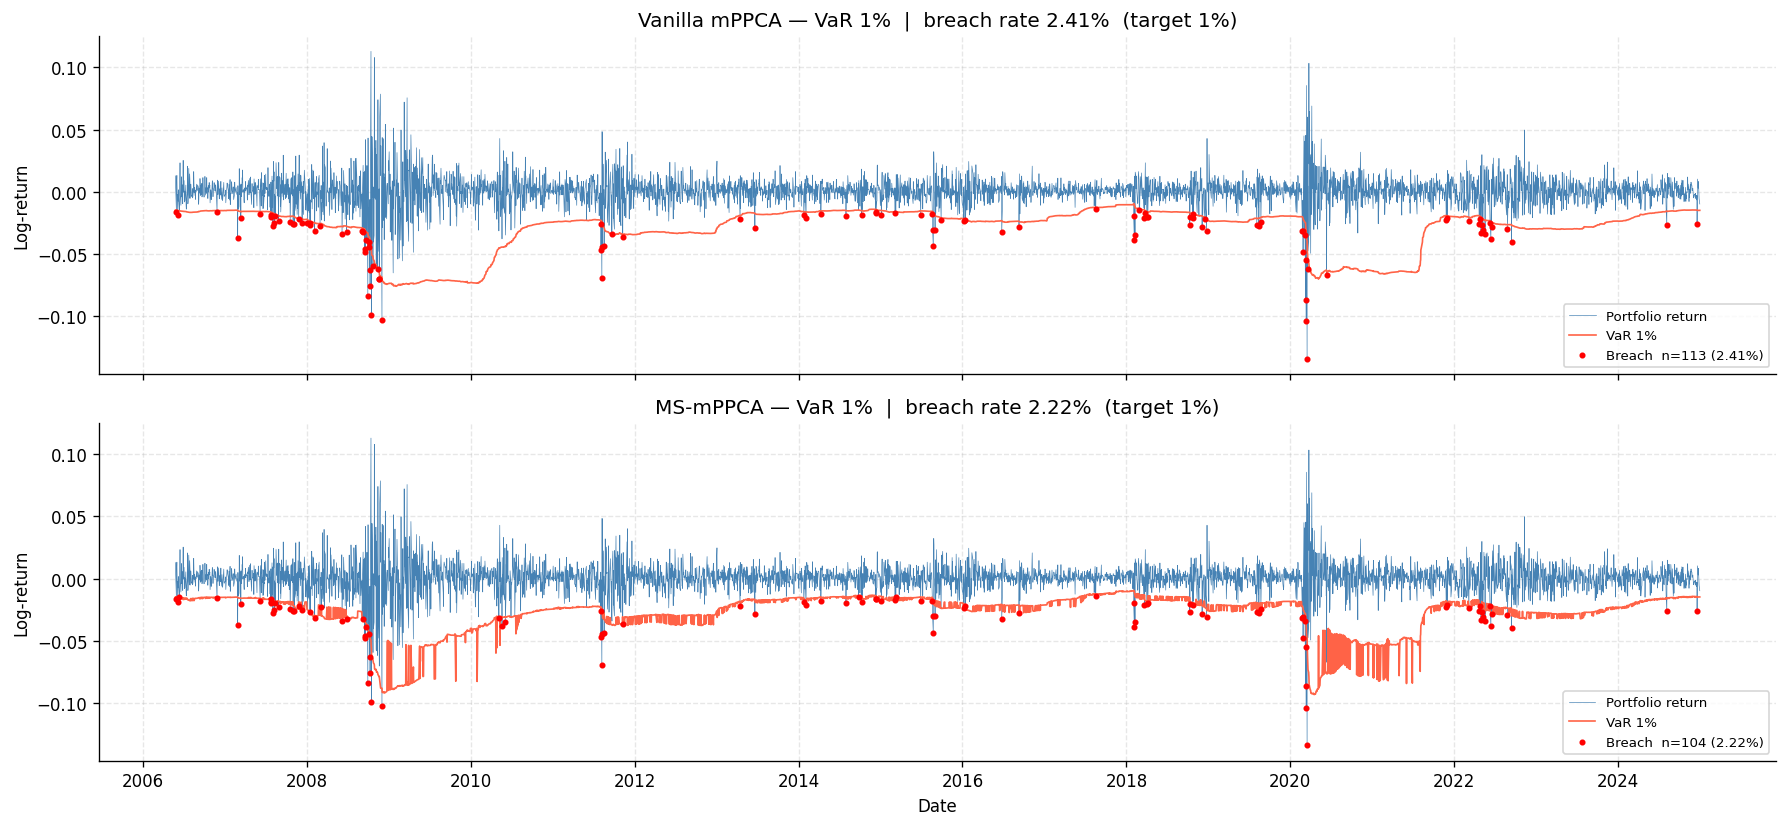

In [43]:
for alpha in ALPHAS:
    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    for ax, (label, var_series) in zip(axes, [
        ('Vanilla mPPCA', vars_v_eq[alpha][0]),
        ('MS-mPPCA',      vars_ms_eq[alpha][0]),
    ]):
        hits = breach_series(port_oos, var_series)
        ax.plot(oos_dates, port_oos, lw=0.4, color='steelblue', label='Portfolio return')
        ax.plot(oos_dates, var_series, lw=1.0, color='tomato',
                label=f'VaR {int(alpha*100)}%')
        ax.scatter(oos_dates[hits == 1], port_oos[hits == 1],
                   s=7, color='red', zorder=5,
                   label=f'Breach  n={hits.sum()} ({hits.mean()*100:.2f}%)')
        ax.set_title(f'{label} — VaR {int(alpha*100)}%  |  breach rate {hits.mean()*100:.2f}%  (target {alpha*100:.0f}%)')
        ax.set_ylabel('Log-return')
        ax.legend(loc='lower right', fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{MS_RUN_DIR}/fig_var_compare_{int(alpha*100)}.png', bbox_inches='tight')
    plt.show()

## 6. Бэктест: Купик и Кристофферсен — сравнение

In [44]:
COLS = ['breach_rate', 'pvalue', 'pvalue_pass', 'ci_95_pass', 'ci_99_pass', 'ind_pass']
COL_RENAME = {
    'breach_rate': 'Breach rate',
    'pvalue'     : 'p-value (Kupiec)',
    'pvalue_pass': 'Kupiec passed',
    'ci_95_pass' : 'CI 95% passed',
    'ci_99_pass' : 'CI 99% passed',
    'ind_pass'   : 'Christoffersen passed',
}

for port_label, portfolios, v_vars, ms_vars in [
    ('Diversified',  portfolios_div,    vars_vanilla_div, vars_ms_div),
    ('Concentrated', portfolios_nondiv, vars_vanilla_nd,  vars_ms_nd),
]:
    print(f'\n{"="*65}')
    print(f'  {port_label} portfolios')
    print('='*65)
    rows = []
    for alpha in ALPHAS:
        v  = aggregate_results(portfolios, oos_ret, v_vars[alpha],  alpha)
        ms_ = aggregate_results(portfolios, oos_ret, ms_vars[alpha], alpha)
        v.index   = [f'Vanilla   α={alpha}']
        ms_.index = [f'MS-mPPCA  α={alpha}']
        rows += [v, ms_]
    df = pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4)
    display(df)


  Diversified portfolios


,Breach rate,p-value (Kupiec),Kupiec passed,CI 95% passed,CI 99% passed,Christoffersen passed
Vanilla α=0.05,0.0592,0.0050,0.0,0.00,0.045,0.000
MS-mPPCA α=0.05,0.0570,0.0324,0.1,0.18,1.000,0.000
Vanilla α=0.01,0.0240,0.0000,0.0,0.00,0.000,0.000
MS-mPPCA α=0.01,0.0219,0.0000,0.0,0.00,0.000,0.455



  Concentrated portfolios


,Breach rate,p-value (Kupiec),Kupiec passed,CI 95% passed,CI 99% passed,Christoffersen passed
Vanilla α=0.05,0.0548,0.2463,0.635,0.655,0.795,0.050
MS-mPPCA α=0.05,0.0524,0.3702,0.820,0.830,0.955,0.340
Vanilla α=0.01,0.0189,0.0004,0.005,0.005,0.005,0.235
MS-mPPCA α=0.01,0.0174,0.0027,0.015,0.015,0.030,0.435


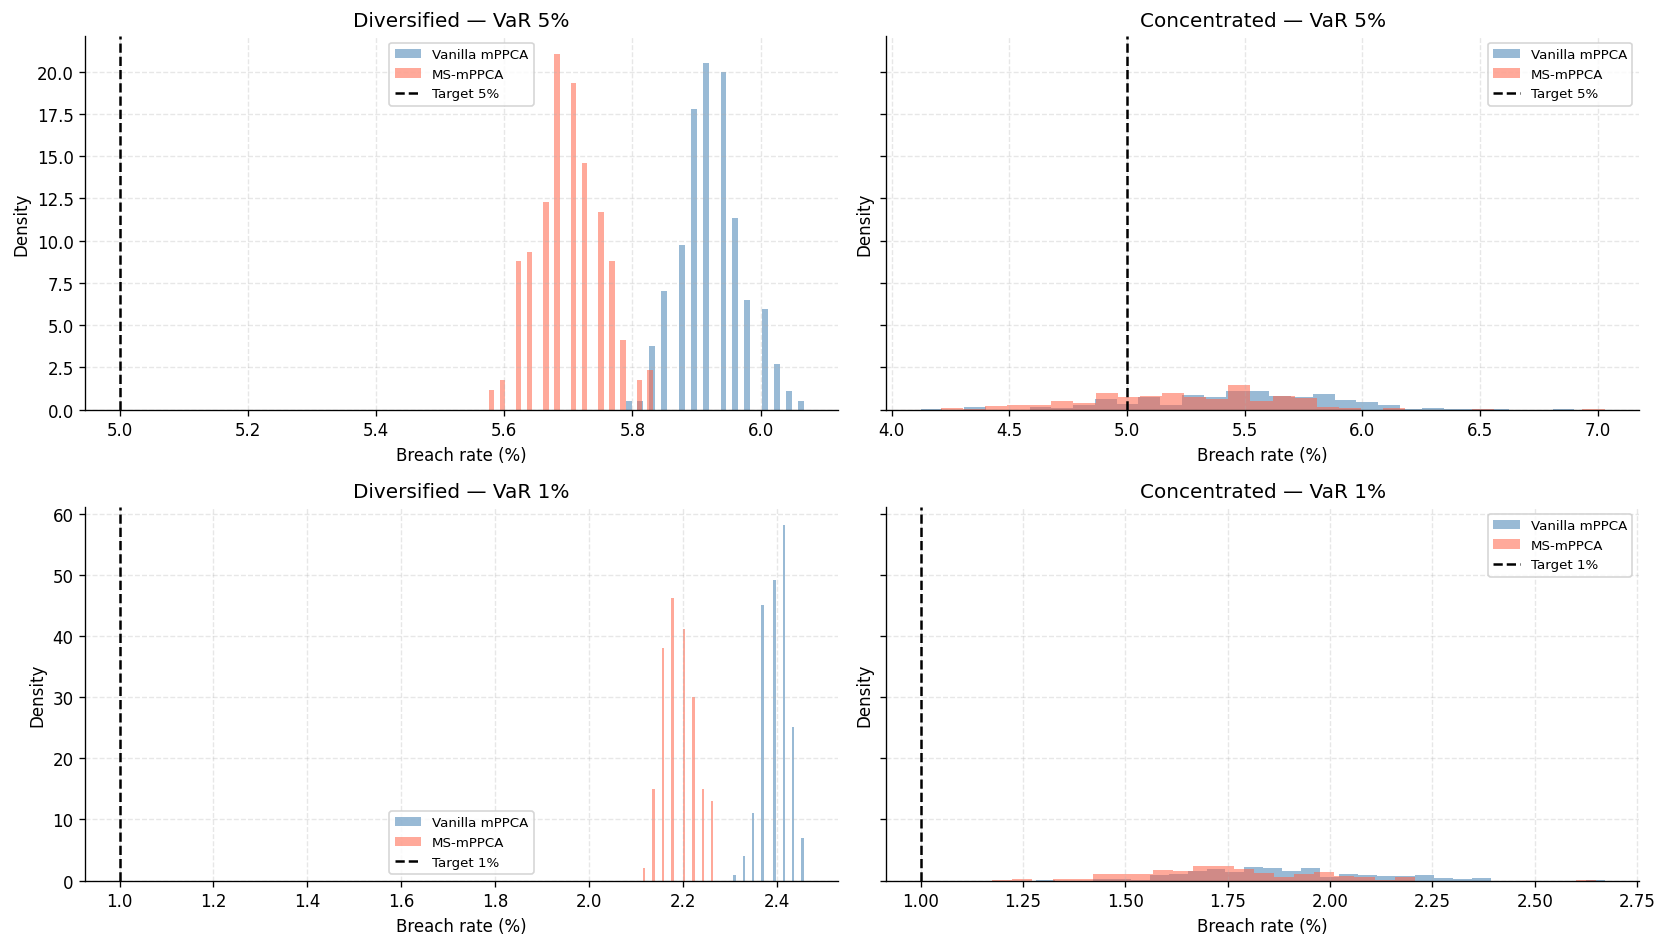

In [45]:
# Breach rate distribution comparison
fig, axes = plt.subplots(len(ALPHAS), 2, figsize=(14, 4 * len(ALPHAS)), sharey='row')

for row, alpha in enumerate(ALPHAS):
    for col, (port_label, portfolios, v_vars, ms_vars) in enumerate([
        ('Diversified',  portfolios_div,    vars_vanilla_div, vars_ms_div),
        ('Concentrated', portfolios_nondiv, vars_vanilla_nd,  vars_ms_nd),
    ]):
        ax = axes[row, col]
        for label, vars_m, color in [
            ('Vanilla mPPCA', v_vars[alpha],  'steelblue'),
            ('MS-mPPCA',      ms_vars[alpha], 'tomato'),
        ]:
            rates = np.array([
                breach_series(oos_ret @ portfolios[j], vars_m[j]).mean()
                for j in range(len(portfolios))
            ]) * 100
            ax.hist(rates, bins=30, alpha=0.55, label=label, color=color, density=True)
        ax.axvline(alpha * 100, color='black', ls='--', lw=1.5,
                   label=f'Target {alpha*100:.0f}%')
        ax.set_title(f'{port_label} — VaR {int(alpha*100)}%')
        ax.set_xlabel('Breach rate (%)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{MS_RUN_DIR}/fig_breach_compare.png', bbox_inches='tight')
plt.show()

## 7. Выводы

### Результаты

- **Log-likelihood**: MS-mPPCA превосходит Vanilla в 99.1% окон, средний прирост +30.91. Марковская структура фиксирует информацию о последовательностях, которую i.i.d. смесь игнорирует.
- **Режимы**: $A_{kk} \approx 0.8$–$0.99$ — состояния персистентны. Кризисы 2008 и COVID-2020 видны как длительные пребывания в высоковолатильном режиме.
- **Купик**: для концентрированных α=5% — 82% прохождений (MS) против 63.5% (Vanilla). Диверсифицированные пока не удаётся откалибровать — нужна t-VaR коррекция.
- **Кристоффэрсен**: концентрированные α=1% — 43.5% (MS) против 23.5% (Vanilla). Режимная структура частично снижает кластеризацию нарушений.

### Ограничения

- **Гауссовы эмиссии**: VaR 1% недооценивается — breach rate 2.19% vs 1% для диверсифицированных.
- **Дискретные переходы**: марковская цепь предполагает мгновенную смену режима; реальные переходы (нарастание кризиса 2008) постепенные.
- **Локальные оптимумы**: EM чувствителен к инициализации; при нестабильном label switching нужна диагностика.

### Дальнейшие шаги

- **Student-t VaR** (`student-t-comparison.ipynb`): заменить $\Phi^{-1}(\alpha)$ на $t_\nu^{-1}(\alpha)$ с откалиброванным $\nu$ — без переобучения. Устраняет проблему VaR 1%.
- **K=3** (`k3-regime-comparison.ipynb`): разделить умеренный и экстремальный стресс — возможное улучшение Кристоффэрсена.